# load libraries

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from impedance.models.circuits import CustomCircuit
import warnings
import itertools # generate all possible combinations of elements in lists
import re
from tqdm import tqdm
import random
import pickle
import os


random.seed(42)
np.random.seed(42)

# Suppress the specific warning from impedance.py
warnings.filterwarnings("ignore", category=UserWarning, 
                        message="Simulating circuit based on initial parameters")

# Added by Yonatan
# Some control variables
file_path = "data/EIS_test.pkl"
n_combinations = 100
# Frequency
frequencies = None  # Use default frequencies
# frequencies = np.logspace(4, -2, 80)

# generate EIS data

In [4]:
# create an empty dictionary where I will write all data

EIS_dataset = {}

R0 = R1 = R2 = R3 = 0
C0 = C1 = C2 = C3 = 0
CPE0 = CPE1 = CPE2 = CPE3 = 0
CPE_alpha = 0
L0 = L1 = L2 = L3 = 0
Wo_0 = Wo_1 = 0

# save the result

In [5]:
# Save the dictionary to the Pickle file
if file_path is not None:
    # Ensure parent directory exists
    dirpath = os.path.dirname(file_path)
    if dirpath and not os.path.exists(dirpath):
        os.makedirs(dirpath, exist_ok=True)
    # If the file doesn't exist, create it and write the dataset
    if not os.path.exists(file_path):
        with open(file_path, 'wb') as file:
            pickle.dump(EIS_dataset, file)
    else:
        # If file exists and contains a dict, merge; otherwise overwrite
        try:
            with open(file_path, 'rb') as file:
                existing = pickle.load(file)
            if isinstance(existing, dict):
                existing.update(EIS_dataset)
                with open(file_path, 'wb') as file:
                    pickle.dump(existing, file)
            else:
                with open(file_path, 'wb') as file:
                    pickle.dump(EIS_dataset, file)
        except Exception:
            with open(file_path, 'wb') as file:
                pickle.dump(EIS_dataset, file)

# Yonatan's follow up

In [6]:
if len(circuits) == 0:
    print('No circuits to plot')
else:
    for circuit in circuits:
        plt.figure()
        plt.title(f"Circuit: {circuit}")
        for Z in np.vstack(EIS_dataset[circuit]):
            # Calculate the range for both real and imaginary parts
            re_range = Z.real.max() - Z.real.min()
            im_range = Z.imag.max() - Z.imag.min()
            
            # Apply normalization only if the range is greater than 0
            if re_range > 0:
                Zre_norm = (Z.real - Z.real.min()) / re_range
            else:
                Zre_norm = np.zeros_like(Z.real) # Default to 0s if constant
                
            if im_range > 0:
                Zim_norm = (Z.imag - Z.imag.min()) / im_range
            else:
                Zim_norm = np.zeros_like(Z.imag) # Default to 0s if constant
                
            plt.plot(Zre_norm, -Zim_norm)
        plt.xlabel(r"$\text{Re}(Z)$")
        plt.ylabel(r"$-\text{Im}(Z)$")

plt.show()

NameError: name 'circuits' is not defined

## optimize diverse parameter sets for `R0-p(CPE1,R1)-p(CPE2,R2)`

In [ ]:
# Diverse-curve search for the ECM: R0-p(CPE1,R1)-p(CPE2,R2)

if frequencies is None:
    frequencies = np.logspace(5, -2, 80)

circuit = 'R0-p(CPE1,R1)-p(CPE2,R2)'

def simulate_ecm(params, frequencies=frequencies):
    initial_guess = [float(value) for value in params]
    try:
        model = CustomCircuit(circuit=circuit, initial_guess=initial_guess)
        return model.predict(frequencies)
    except Exception:
        return None

def normalize_curve(Z):
    real = Z.real
    imag = Z.imag
    real_min, real_max = real.min(), real.max()
    imag_min, imag_max = imag.min(), imag.max()

    if real_max > real_min:
        real_norm = (real - real_min) / (real_max - real_min)
    else:
        real_norm = np.zeros_like(real)

    if imag_max > imag_min:
        imag_norm = (imag - imag_min) / (imag_max - imag_min)
    else:
        imag_norm = np.zeros_like(imag)

    return real_norm, imag_norm

def stack_curves(curves):
    if not curves:
        return np.empty((0, 0, 2), dtype=np.float32)

    n_freq = len(curves[0][0])
    curve_points = np.empty((len(curves), n_freq, 2), dtype=np.float32)
    for idx, (re_norm, im_norm) in enumerate(curves):
        if len(re_norm) != n_freq or len(im_norm) != n_freq:
            raise ValueError('All curves must use the same frequency grid')
        curve_points[idx, :, 0] = re_norm
        curve_points[idx, :, 1] = im_norm

    return curve_points


def distances_to_curve(curve_points, reference_curve):
    diff = curve_points - reference_curve[None, :, :]
    return np.sqrt(np.sum(diff * diff, axis=2)).mean(axis=1)


def curve_distance(curve_a, curve_b):
    points_a = np.vstack(curve_a).T
    points_b = np.vstack(curve_b).T
    return np.mean(np.linalg.norm(points_a - points_b, axis=1))

def sample_candidates(n_candidates=400, seed=42):
    rng = np.random.default_rng(seed)
    candidates = []

    r0_bounds = (1e0, 1e5)
    r_bounds = (1e0, 1e6)
    cpe_bounds = (1e-8, 1e-3)
    alpha_bounds = (0.5, 1.0)

    for _ in range(n_candidates):
        r0 = 10 ** rng.uniform(np.log10(r0_bounds[0]), np.log10(r0_bounds[1]))
        r1 = 10 ** rng.uniform(np.log10(r_bounds[0]), np.log10(r_bounds[1]))
        r2 = 10 ** rng.uniform(np.log10(r_bounds[0]), np.log10(r_bounds[1]))

        cpe1 = 10 ** rng.uniform(np.log10(cpe_bounds[0]), np.log10(cpe_bounds[1]))
        cpe2 = 10 ** rng.uniform(np.log10(cpe_bounds[0]), np.log10(cpe_bounds[1]))

        alpha1 = rng.uniform(alpha_bounds[0], alpha_bounds[1])
        alpha2 = rng.uniform(alpha_bounds[0], alpha_bounds[1])

        candidates.append([r0, cpe1, alpha1, r1, cpe2, alpha2, r2])

    return candidates

def evaluate_candidates(candidates):
    param_list = []
    curves = []

    for params in tqdm(candidates, desc='Simulating candidates'):
        Z = simulate_ecm(params)
        if Z is None:
            continue
        curves.append(normalize_curve(Z))
        param_list.append(params)

    return param_list, curves


def high_frequency_minus_im(curve, high_frequency_index=0):
    return -float(curve[1][high_frequency_index])


def filter_high_frequency_curves(
    param_list,
    curves,
    max_high_frequency_minus_im=-0.8,
    high_frequency_index=0,
):
    high_frequency_values = np.asarray([
        high_frequency_minus_im(curve, high_frequency_index=high_frequency_index)
        for curve in curves
    ])
    keep_mask = high_frequency_values <= max_high_frequency_minus_im
    kept_idx = np.flatnonzero(keep_mask)
    removed_idx = np.flatnonzero(~keep_mask)

    filtered_params = [param_list[i] for i in kept_idx]
    filtered_curves = [curves[i] for i in kept_idx]

    filter_info = {
        'max_high_frequency_minus_im': max_high_frequency_minus_im,
        'high_frequency_index': high_frequency_index,
        'raw_valid_candidate_count': len(param_list),
        'filtered_candidate_count': len(filtered_params),
        'removed_candidate_count': len(removed_idx),
        'kept_original_idx': kept_idx.tolist(),
        'removed_original_idx': removed_idx.tolist(),
        'high_frequency_minus_im': high_frequency_values.tolist(),
    }

    if not filtered_params:
        raise ValueError(
            'High-frequency filter removed every candidate. '
            'Lower max_high_frequency_minus_im or broaden the candidate sampling range.'
        )

    return filtered_params, filtered_curves, filter_info

def choose_initial_curve(curve_points, start='farthest_from_center'):
    if isinstance(start, (int, np.integer)):
        if start < 0 or start >= len(curve_points):
            raise IndexError('start index is outside the candidate range')
        return int(start)

    if start == 'farthest_from_center':
        center_curve = curve_points.mean(axis=0)
        return int(np.argmax(distances_to_curve(curve_points, center_curve)))

    if start == 'random':
        return int(np.random.default_rng(0).integers(len(curve_points)))

    raise ValueError("start must be an index, 'farthest_from_center', or 'random'")


def greedy_select(
    param_list,
    curves,
    k=30,
    start='farthest_from_center',
    min_distance=None,
    return_scores=False,
):
    if not param_list or k <= 0:
        if return_scores:
            return [], [], []
        return [], []

    curve_points = stack_curves(curves)
    n_select = min(k, len(param_list))

    first_idx = choose_initial_curve(curve_points, start=start)
    selected_idx = [first_idx]
    selection_scores = [np.inf]

    min_dist_to_selected = distances_to_curve(curve_points, curve_points[first_idx])
    min_dist_to_selected[first_idx] = -np.inf

    while len(selected_idx) < n_select:
        best_idx = int(np.argmax(min_dist_to_selected))
        best_score = float(min_dist_to_selected[best_idx])

        if min_distance is not None and best_score < min_distance:
            break

        selected_idx.append(best_idx)
        selection_scores.append(best_score)

        new_dist = distances_to_curve(curve_points, curve_points[best_idx])
        min_dist_to_selected = np.minimum(min_dist_to_selected, new_dist)
        min_dist_to_selected[selected_idx] = -np.inf

    selected_params = [param_list[i] for i in selected_idx]
    if return_scores:
        return selected_params, selected_idx, selection_scores
    return selected_params, selected_idx

def plot_selected(curves, selected_idx):
    plt.figure(figsize=(8, 6))
    for idx, (re_norm, im_norm) in enumerate(curves):
        if idx in selected_idx:
            plt.plot(re_norm, -im_norm, linewidth=2.5, alpha=0.95)
        # else:
        #     plt.plot(re_norm, -im_norm, linewidth=0.8, color='gray', alpha=0.25)

    plt.xlabel('Normalized Re(Z)')
    plt.ylabel('Normalized -Im(Z)')
    plt.title('Normalized Nyquist curves: diverse parameter sets')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def transform_parameters_for_pca(param_list):
    params = np.asarray(param_list, dtype=float)
    feature_names = np.array([
        'log10(R0)', 'log10(CPE1)', 'alpha1',
        'log10(R1)', 'log10(CPE2)', 'alpha2', 'log10(R2)',
    ])
    log_columns = [0, 1, 3, 4, 6]

    transformed = params.copy()
    transformed[:, log_columns] = np.log10(transformed[:, log_columns])
    return transformed, feature_names


def plot_parameter_pca_2d(param_list, selected_idx):
    from sklearn.decomposition import PCA
    from sklearn.preprocessing import StandardScaler

    if len(param_list) < 2:
        print('Skipping PCA plot: need at least two parameter sets')
        return None

    X, feature_names = transform_parameters_for_pca(param_list)
    X_scaled = StandardScaler().fit_transform(X)
    pca = PCA(n_components=2)
    scores = pca.fit_transform(X_scaled)

    selected_idx = np.asarray(selected_idx, dtype=int)
    explained = pca.explained_variance_ratio_ * 100

    plt.figure(figsize=(7.5, 6))
    plt.scatter(
        scores[:, 0], scores[:, 1],
        s=24, color='0.78', alpha=0.55, label='All valid candidates',
    )
    plt.scatter(
        scores[selected_idx, 0], scores[selected_idx, 1],
        s=44, color='tab:red', edgecolor='black', linewidth=0.35,
        alpha=0.9, label='Selected curves',
    )

    pc1_top = feature_names[np.argsort(np.abs(pca.components_[0]))[::-1][:3]]
    pc2_top = feature_names[np.argsort(np.abs(pca.components_[1]))[::-1][:3]]
    loading_text = (
        'PC1 top loadings: ' + ', '.join(pc1_top) + '\n'
        'PC2 top loadings: ' + ', '.join(pc2_top)
    )
    plt.gca().text(
        0.02, 0.98, loading_text,
        transform=plt.gca().transAxes,
        va='top', ha='left', fontsize=9,
        bbox={'boxstyle': 'round,pad=0.35', 'facecolor': 'white', 'edgecolor': '0.85', 'alpha': 0.9},
    )

    plt.xlabel(f'PC1 ({explained[0]:.1f}% variance)')
    plt.ylabel(f'PC2 ({explained[1]:.1f}% variance)')
    plt.title('2D PCA of element parameters')
    plt.grid(True, alpha=0.3)
    plt.legend(frameon=False, loc='best')
    plt.tight_layout()
    plt.show()

    return {
        'scores': scores,
        'explained_variance_ratio': pca.explained_variance_ratio_,
        'components': pca.components_,
        'feature_names': feature_names.tolist(),
    }


def plot_curve_pca_2d(curves, selected_idx):
    from sklearn.decomposition import PCA
    from sklearn.preprocessing import StandardScaler

    if len(curves) < 2:
        print('Skipping curve PCA plot: need at least two curves')
        return None

    curve_points = stack_curves(curves)
    X = curve_points.reshape(len(curves), -1)
    X_scaled = StandardScaler().fit_transform(X)
    pca = PCA(n_components=2)
    scores = pca.fit_transform(X_scaled)

    selected_idx = np.asarray(selected_idx, dtype=int)
    explained = pca.explained_variance_ratio_ * 100

    plt.figure(figsize=(7.5, 6))
    plt.scatter(
        scores[:, 0], scores[:, 1],
        s=24, color='0.78', alpha=0.55, label='All valid candidates',
    )
    plt.scatter(
        scores[selected_idx, 0], scores[selected_idx, 1],
        s=44, color='tab:red', edgecolor='black', linewidth=0.35,
        alpha=0.9, label='Selected curves',
    )

    plt.xlabel(f'PC1 ({explained[0]:.1f}% variance)')
    plt.ylabel(f'PC2 ({explained[1]:.1f}% variance)')
    plt.title('2D PCA of normalized Nyquist curves')
    plt.grid(True, alpha=0.3)
    plt.legend(frameon=False, loc='best')
    plt.tight_layout()
    plt.show()

    return {
        'scores': scores,
        'explained_variance_ratio': pca.explained_variance_ratio_,
        'components': pca.components_,
    }

Simulating candidates: 100%|██████████| 1000/1000 [00:00<00:00, 1332.33it/s]


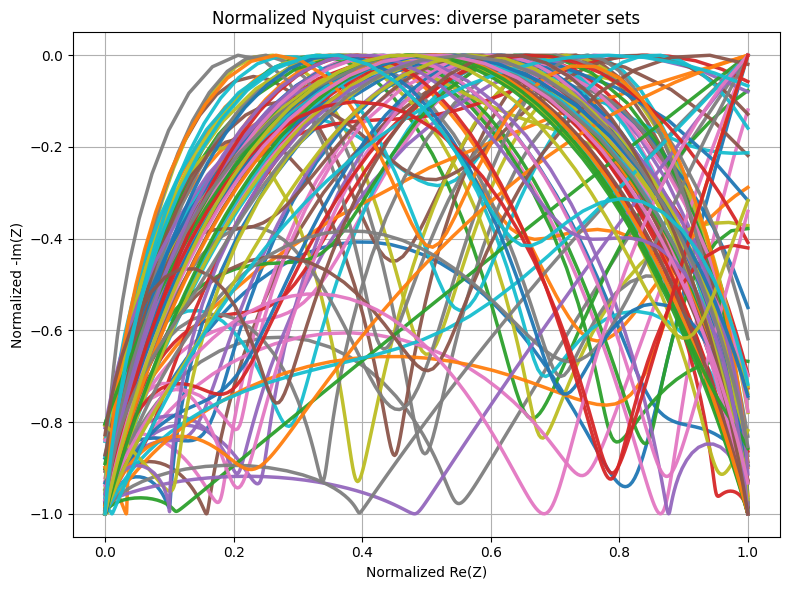

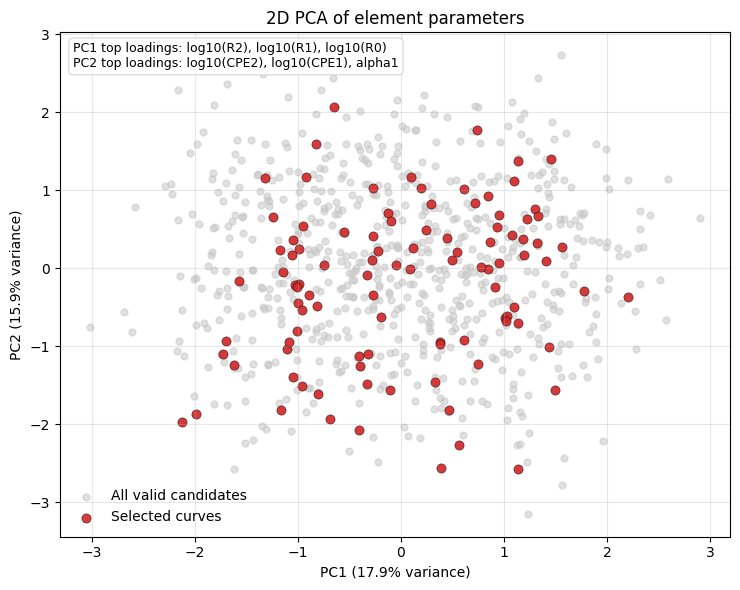

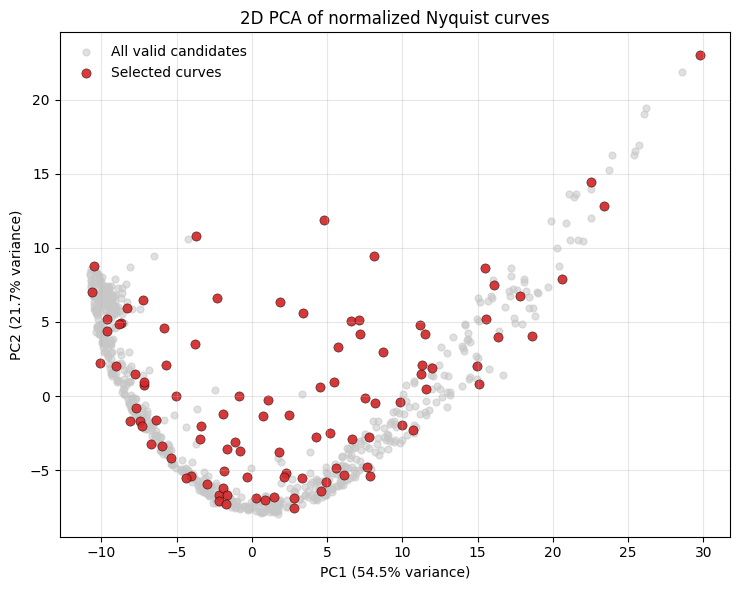

Saved parameters to: data/optimized_params.pkl
High-frequency filter kept 765 of 1000 valid candidates (-Im_norm[0] <= -0.8)
Selected 100 curves out of 765 filtered candidates


In [ ]:
# Run the search
candidates = sample_candidates(n_candidates=1000, seed=42)
raw_param_list, raw_curves = evaluate_candidates(candidates)

# Keep only curves whose high-frequency endpoint is near the bottom of the
# normalized Nyquist plot. Since the plotted y-value is -im_norm, this removes
# curves whose high-frequency endpoint starts above -0.8.
high_frequency_index = 0
max_high_frequency_minus_im = -0.8
param_list, curves, high_frequency_filter_info = filter_high_frequency_curves(
    raw_param_list,
    raw_curves,
    max_high_frequency_minus_im=max_high_frequency_minus_im,
    high_frequency_index=high_frequency_index,
)

max_selected_curves = 100
# Set this to a positive value, for example 0.02, to stop once each new curve
# adds less than that much normalized curve-distance coverage.
distance_threshold = None

selected_params, selected_idx, selection_scores = greedy_select(
    param_list,
    curves,
    k=max_selected_curves,
    start='farthest_from_center',
    min_distance=distance_threshold,
    return_scores=True,
)

plot_selected(curves, selected_idx)
parameter_pca_result = plot_parameter_pca_2d(param_list, selected_idx)
curve_pca_result = plot_curve_pca_2d(curves, selected_idx)

result_path = os.path.join('data', 'optimized_params.pkl')
os.makedirs(os.path.dirname(result_path), exist_ok=True)
with open(result_path, 'wb') as f:
    pickle.dump(
        {
            'selected_params': selected_params,
            'selected_idx': selected_idx,
            'selection_scores': selection_scores,
            'max_selected_curves': max_selected_curves,
            'distance_threshold': distance_threshold,
            'high_frequency_filter_info': high_frequency_filter_info,
            'parameter_pca_result': parameter_pca_result,
            'curve_pca_result': curve_pca_result,
        },
        f,
    )

print('Saved parameters to:', result_path)
print(
    f"High-frequency filter kept {high_frequency_filter_info['filtered_candidate_count']} "
    f"of {high_frequency_filter_info['raw_valid_candidate_count']} valid candidates "
    f"(-Im_norm[{high_frequency_index}] <= {max_high_frequency_minus_im})"
)
print(f'Selected {len(selected_idx)} curves out of {len(param_list)} filtered candidates')
if distance_threshold is not None and len(selected_idx) < min(max_selected_curves, len(param_list)):
    print(f'Stopped because next coverage gain was below {distance_threshold:g}')

FPS sampling for greedy

Picking the range of elements and freq

Finding the measurement of overlapping

principle component analysis (scikit learn) - Telling me which combination of columns we should pick

Try to have a method to detect the curves we pick that not located at top left

Check if there is a method to know the parameters of each curves we pick 
- Create two lists, one for good curves, one for bad curves

For FPS Sampling & our own greedy

- Decided still using our own algorithm, cuz FPS lib is flatting the curves and calculating the Eucliden distance, however we are comparing the whole curve distance based on their shape

- We preprocess the curves into Numpy array, using vectors calculation to sub the original loop

- Has "max_selected_curves" & "distance_threshold" as parameters to control the curves generated


PCA Plotting

- We add PCA 2D plots, showing the top 3 influencing of each axis, and each axis weight of explanation of whole graph

- Example only giving around 31.5% explanation of whole parameters

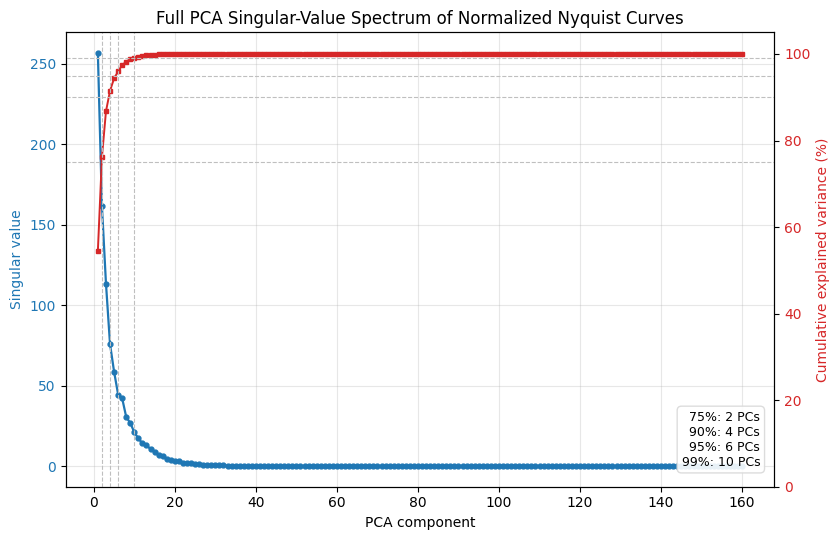

Components needed for cumulative explained variance:
  75%: 2
  90%: 4
  95%: 6
  99%: 10


In [ ]:
# Full singular-value spectrum for the normalized Nyquist-curve PCA
# Run the diverse-curve search cell first so that `curves` is available.

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


def plot_curve_pca_singular_values(curves):
    if len(curves) < 2:
        raise ValueError('Need at least two curves to compute a PCA spectrum')

    curve_points = stack_curves(curves)
    X = curve_points.reshape(len(curves), -1)
    X_scaled = StandardScaler().fit_transform(X)

    n_components = min(X_scaled.shape)
    pca_full = PCA(n_components=n_components)
    pca_full.fit(X_scaled)

    singular_values = pca_full.singular_values_
    explained_ratio = pca_full.explained_variance_ratio_
    cumulative_explained = np.cumsum(explained_ratio)
    dims = np.arange(1, len(singular_values) + 1)

    fig, ax1 = plt.subplots(figsize=(8.5, 5.5))
    ax1.plot(dims, singular_values, marker='o', markersize=3.5, linewidth=1.6, color='tab:blue')
    ax1.set_xlabel('PCA component')
    ax1.set_ylabel('Singular value', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    ax2.plot(dims, cumulative_explained * 100, marker='s', markersize=3, linewidth=1.4, color='tab:red')
    ax2.set_ylabel('Cumulative explained variance (%)', color='tab:red')
    ax2.tick_params(axis='y', labelcolor='tab:red')
    ax2.set_ylim(0, 105)

    thresholds = [0.75, 0.90, 0.95, 0.99]
    summary_lines = []
    for threshold in thresholds:
        n_needed = int(np.searchsorted(cumulative_explained, threshold) + 1)
        if n_needed <= len(cumulative_explained):
            ax2.axhline(threshold * 100, color='0.75', linestyle='--', linewidth=0.8)
            ax2.axvline(n_needed, color='0.75', linestyle='--', linewidth=0.8)
            summary_lines.append(f'{int(threshold * 100)}%: {n_needed} PCs')

    ax1.set_title('Full PCA Singular-Value Spectrum of Normalized Nyquist Curves')
    ax1.text(
        0.98, 0.04, '\n'.join(summary_lines),
        transform=ax1.transAxes,
        ha='right', va='bottom', fontsize=9,
        bbox={'boxstyle': 'round,pad=0.35', 'facecolor': 'white', 'edgecolor': '0.85', 'alpha': 0.9},
    )

    fig.tight_layout()
    plt.show()

    return {
        'singular_values': singular_values,
        'explained_variance_ratio': explained_ratio,
        'cumulative_explained_variance_ratio': cumulative_explained,
        'n_components_for_thresholds': {
            f'{int(threshold * 100)}%': int(np.searchsorted(cumulative_explained, threshold) + 1)
            for threshold in thresholds
        },
    }


curve_pca_spectrum = plot_curve_pca_singular_values(curves)

print('Components needed for cumulative explained variance:')
for threshold, n_components in curve_pca_spectrum['n_components_for_thresholds'].items():
    print(f'  {threshold}: {n_components}')


In [ ]:
# Corner plot for the first 15 Nyquist-curve PCA directions with clustered selected-point detection
# Run the diverse-curve search cell first so that `curves`, `selected_idx`, and `param_list` are available.

import corner
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import StandardScaler

parameter_columns = ['R0', 'CPE1', 'alpha1', 'R1', 'CPE2', 'alpha2', 'R2']


def compute_curve_pca_scores(curves, n_pcs=15):
    if len(curves) < 2:
        raise ValueError('Need at least two curves to compute PCA scores')

    curve_points = stack_curves(curves)
    X = curve_points.reshape(len(curves), -1)
    X_scaled = StandardScaler().fit_transform(X)

    n_pcs = min(n_pcs, X_scaled.shape[0], X_scaled.shape[1])
    pca = PCA(n_components=n_pcs)
    scores = pca.fit_transform(X_scaled)

    return {
        'scores': scores,
        'explained_variance_ratio': pca.explained_variance_ratio_,
        'cumulative_explained_variance_ratio': np.cumsum(pca.explained_variance_ratio_),
        'components': pca.components_,
    }


def detect_clustered_selected_points(
    scores,
    selected_idx,
    nn_bad_percentile=20,
    dbscan_eps_percentile=25,
    dbscan_min_samples=3,
):
    selected_idx_array = np.asarray(selected_idx, dtype=int)
    selected_scores = scores[selected_idx_array]

    if len(selected_idx_array) < 2:
        raise ValueError('Need at least two selected points to detect clustered selections')

    selected_distances = pairwise_distances(selected_scores)
    np.fill_diagonal(selected_distances, np.inf)

    nearest_position = np.argmin(selected_distances, axis=1)
    nearest_distance = selected_distances[np.arange(len(selected_idx_array)), nearest_position]
    nearest_idx = selected_idx_array[nearest_position]

    nn_threshold = float(np.percentile(nearest_distance, nn_bad_percentile))
    nn_bad = nearest_distance <= nn_threshold

    dbscan_eps = float(np.percentile(nearest_distance, dbscan_eps_percentile))
    if dbscan_eps <= 0:
        positive_distances = nearest_distance[nearest_distance > 0]
        dbscan_eps = float(positive_distances.min()) if len(positive_distances) else 1e-12

    dbscan = DBSCAN(eps=dbscan_eps, min_samples=dbscan_min_samples)
    dbscan_labels = dbscan.fit_predict(selected_scores)
    dbscan_bad = dbscan_labels != -1

    flags_df = pd.DataFrame({
        'candidate_idx': selected_idx_array,
        'selection_order': np.arange(1, len(selected_idx_array) + 1),
        'nearest_selected_idx': nearest_idx,
        'nearest_selected_distance': nearest_distance,
        'nn_bad_threshold': nn_threshold,
        'bad_by_nn_percentile': nn_bad,
        'dbscan_eps': dbscan_eps,
        'dbscan_min_samples': dbscan_min_samples,
        'dbscan_cluster_label': dbscan_labels,
        'bad_by_dbscan': dbscan_bad,
    })
    flags_df['bad_by_either_method'] = flags_df['bad_by_nn_percentile'] | flags_df['bad_by_dbscan']

    return flags_df


def plot_curve_pca_corner(
    pca_result,
    selected_idx,
    bad_selected_idx=None,
    bad_label='clustered selected',
):
    scores = pca_result['scores']
    explained = pca_result['explained_variance_ratio'] * 100
    cumulative = pca_result['cumulative_explained_variance_ratio'] * 100
    n_pcs = scores.shape[1]

    selected_idx_array = np.asarray(selected_idx, dtype=int)
    selected_scores = scores[selected_idx_array]
    bad_selected_idx = [] if bad_selected_idx is None else list(bad_selected_idx)
    bad_selected_scores = scores[np.asarray(bad_selected_idx, dtype=int)] if bad_selected_idx else np.empty((0, n_pcs))

    labels = [f'PC{i + 1} ({explained[i]:.3f}%)' for i in range(n_pcs)]

    fig = corner.corner(
        scores,
        labels=labels,
        color='0.55',
        bins=28,
        plot_datapoints=True,
        plot_density=False,
        plot_contours=False,
        data_kwargs={'alpha': 0.20, 'ms': 1.5},
        hist_kwargs={'color': '0.55', 'alpha': 0.40, 'density': True},
        label_kwargs={'fontsize': 8},
    )

    axes = np.asarray(fig.axes).reshape((n_pcs, n_pcs))
    for row in range(n_pcs):
        axes[row, row].hist(
            selected_scores[:, row],
            bins=28,
            color='tab:red',
            alpha=0.40,
            density=True,
        )
        if len(bad_selected_scores):
            axes[row, row].hist(
                bad_selected_scores[:, row],
                bins=28,
                color='tab:blue',
                alpha=0.65,
                density=True,
            )
        for col in range(row):
            axes[row, col].plot(
                selected_scores[:, col],
                selected_scores[:, row],
                '.',
                color='tab:red',
                alpha=0.70,
                markersize=2.5,
            )
            if len(bad_selected_scores):
                axes[row, col].plot(
                    bad_selected_scores[:, col],
                    bad_selected_scores[:, row],
                    '.',
                    color='tab:blue',
                    alpha=0.95,
                    markersize=4.2,
                )

    fig.suptitle(
        f'Corner Plot of First {n_pcs} Nyquist-Curve PCA Directions '
        f'(cumulative explained variance: {cumulative[-1]:.3f}%)\n'
        f'Blue = {bad_label}; red = all selected; gray = all candidates',
        y=1.01,
        fontsize=13,
    )

    plt.show()

    return fig


def build_selected_cluster_table(param_list, pca_result, selected_flags_df):
    params = np.asarray(param_list, dtype=float)
    selected_idx_array = selected_flags_df['candidate_idx'].to_numpy(dtype=int)
    selected_params_df = pd.DataFrame(params[selected_idx_array], columns=parameter_columns)
    pc_scores_df = pd.DataFrame(
        pca_result['scores'][selected_idx_array],
        columns=[f'PC{i + 1}' for i in range(pca_result['scores'].shape[1])],
    )
    return pd.concat(
        [selected_flags_df.reset_index(drop=True), selected_params_df, pc_scores_df],
        axis=1,
    )


corner_n_pcs = 15
nn_bad_percentile = 20
# DBSCAN uses this nearest-neighbor percentile as eps; increase it if it finds no clusters.
dbscan_eps_percentile = 25
dbscan_min_samples = 3

curve_pca_corner_result = compute_curve_pca_scores(curves, n_pcs=corner_n_pcs)
selected_cluster_flags_df = detect_clustered_selected_points(
    curve_pca_corner_result['scores'],
    selected_idx,
    nn_bad_percentile=nn_bad_percentile,
    dbscan_eps_percentile=dbscan_eps_percentile,
    dbscan_min_samples=dbscan_min_samples,
)
selected_cluster_table_df = build_selected_cluster_table(
    param_list,
    curve_pca_corner_result,
    selected_cluster_flags_df,
)

# corner_scores_path = os.path.join('data', f'curve_pca_{corner_n_pcs}_scores.csv')
corner_scores_df = pd.DataFrame(
    curve_pca_corner_result['scores'],
    columns=[f'PC{i + 1}' for i in range(curve_pca_corner_result['scores'].shape[1])],
)
corner_scores_df.insert(0, 'candidate_idx', np.arange(len(corner_scores_df)))
# corner_scores_df['is_selected'] = corner_scores_df['candidate_idx'].isin(selected_idx)
# corner_scores_df.to_csv(corner_scores_path, index=False)

# cluster_table_path = os.path.join('data', f'selected_cluster_flags_{corner_n_pcs}pc.csv')
# selected_cluster_table_df.to_csv(cluster_table_path, index=False)

nn_bad_idx = selected_cluster_flags_df.loc[
    selected_cluster_flags_df['bad_by_nn_percentile'], 'candidate_idx'
].tolist()
dbscan_bad_idx = selected_cluster_flags_df.loc[
    selected_cluster_flags_df['bad_by_dbscan'], 'candidate_idx'
].tolist()

plot_curve_pca_corner(
    curve_pca_corner_result,
    selected_idx,
    bad_selected_idx=nn_bad_idx,
    bad_label=f'nearest-neighbor bottom {nn_bad_percentile}%',
)
plot_curve_pca_corner(
    curve_pca_corner_result,
    selected_idx,
    bad_selected_idx=dbscan_bad_idx,
    bad_label=f'DBSCAN clustered selected, eps={selected_cluster_flags_df["dbscan_eps"].iloc[0]:.3g}',
)

print(f'Cumulative explained variance for {corner_n_pcs} PCs:', f"{curve_pca_corner_result['cumulative_explained_variance_ratio'][-1] * 100:.3f}%")
# print('Saved PCA scores to:', corner_scores_path)
# print('Saved selected cluster flags to:', cluster_table_path)
print(f'Nearest-neighbor bad selected count: {len(nn_bad_idx)} / {len(selected_idx)}')
print(f'DBSCAN bad selected count: {len(dbscan_bad_idx)} / {len(selected_idx)}')

display_columns = [
    'candidate_idx', 'selection_order', 'nearest_selected_idx', 'nearest_selected_distance',
    'bad_by_nn_percentile', 'dbscan_cluster_label', 'bad_by_dbscan', 'bad_by_either_method',
    'R0', 'CPE1', 'alpha1', 'R1', 'CPE2', 'alpha2', 'R2',
]
print('\nSelected samples flagged as bad by either method')
display(
    selected_cluster_table_df.loc[
        selected_cluster_table_df['bad_by_either_method'], display_columns
    ].sort_values('nearest_selected_distance')
)


Uniform Mainfold Approximation and projection (Umap) python
- Slower PCA, but can detect more shape
- BlackBox inside
- Use provided dataset to generate and setup the Umap throught the Umap Link

Drop_ECM_function, calling it, try applying it towards my data (input: ECM, f, Z, p)
Simplify function: Simplify the ECM

Combine them

- Use these to try different EIS data (with the ECM upward) if works, we add a group of -[R,P]-
- Use Umap to check the relabel functionality

## UMAP visualization for `R-[P,R]-[P,R]` from `data/training_dataset.pkl`

Loads the normalized impedance vectors from `flatten_Z`, uses `true_circuit` as the color label, and highlights `R-[P,R]-[P,R]` if that ECM is present in the training dataset.


/var/folders/ym/q5wh54d16f9dl513jp182byh0000gn/T/ipykernel_27862/3206323304.py:19: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  training_dataset = pickle.load(f)


No rows matching R-[P,R]-[P,R] were found in data/training_dataset.pkl.
Available true_circuit labels:
  R1-[R2,C3]: 270
  R1-[R2-P3,C4]: 270
  R1-[R2-[R3,C4],C5]: 270
  R1-[R2,C3]-[R4,C5]-P6: 270
  R1-[R2,C3]-[R4,C5]-[R6,C7]: 270


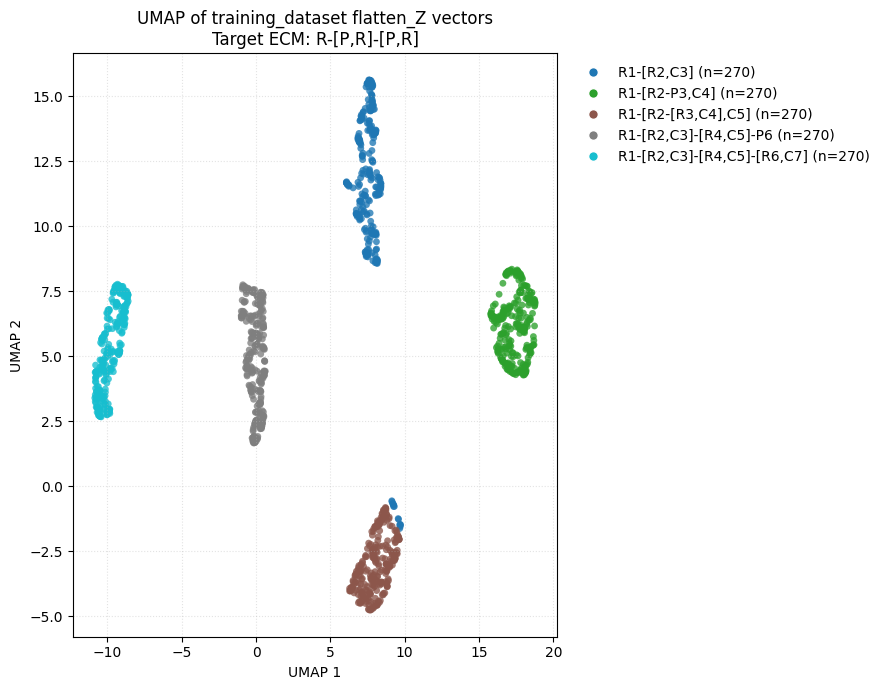

In [ ]:
# UMAP visualization from the prepared training dataset
# UMAP documentation uses reducer = umap.UMAP(...), followed by fit_transform(X),
# then plotting embedding[:, 0] vs embedding[:, 1].

import pickle
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import umap
from matplotlib.lines import Line2D

training_dataset_path = Path('data/training_dataset.pkl')
target_ecm = 'R-[P,R]-[P,R]'

with training_dataset_path.open('rb') as f:
    training_dataset = pickle.load(f)

required_columns = {'flatten_Z', 'true_circuit'}
missing_columns = required_columns.difference(training_dataset.columns)
if missing_columns:
    raise KeyError(f'Missing required columns in {training_dataset_path}: {sorted(missing_columns)}')


def canonical_ecm_label(label):
    # Match labels that differ only by element indices, whitespace, or CPE spelling.
    label = str(label).replace(' ', '')
    label = label.replace('CPE', 'P')
    label = re.sub(r'\d+', '', label)
    return label


labels = training_dataset['true_circuit'].astype(str)
label_codes, label_names = pd.factorize(labels)
X = np.vstack(training_dataset['flatten_Z'].map(np.asarray).to_numpy()).astype(float)

target_key = canonical_ecm_label(target_ecm)
target_mask = labels.map(canonical_ecm_label).eq(target_key).to_numpy()

if target_mask.any():
    print(f'Found {target_mask.sum()} rows matching {target_ecm}')
else:
    print(f'No rows matching {target_ecm} were found in {training_dataset_path}.')
    print('Available true_circuit labels:')
    for circuit_label, count in labels.value_counts().items():
        print(f'  {circuit_label}: {count}')

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric='euclidean',
    random_state=42,
    n_jobs=1,
)
embedding = reducer.fit_transform(X)

fig, ax = plt.subplots(figsize=(9, 7))
scatter = ax.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=label_codes,
    cmap='tab10',
    s=24,
    alpha=0.78,
    linewidths=0,
)

if target_mask.any():
    ax.scatter(
        embedding[target_mask, 0],
        embedding[target_mask, 1],
        facecolors='none',
        edgecolors='black',
        s=90,
        linewidths=1.4,
        label=f'Target: {target_ecm}',
    )

legend_handles = [
    Line2D(
        [0],
        [0],
        marker='o',
        color='w',
        label=f'{label_name} (n={(labels == label_name).sum()})',
        markerfacecolor=scatter.cmap(scatter.norm(code)),
        markersize=7,
    )
    for code, label_name in enumerate(label_names)
]
if target_mask.any():
    legend_handles.append(
        Line2D(
            [0],
            [0],
            marker='o',
            color='black',
            label=f'Target highlight: {target_ecm}',
            markerfacecolor='none',
            markersize=9,
            linewidth=0,
        )
    )

ax.legend(handles=legend_handles, frameon=False, bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_title(f'UMAP of training_dataset flatten_Z vectors\nTarget ECM: {target_ecm}')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.grid(True, linestyle=':', alpha=0.35)
fig.tight_layout()
plt.show()


## Relabel `R1-[R2,C3]-[R4,C5]-[R6,C7]` with simplification then FIM

This cell loads the prepared training dataset, fits parameters for each target ECM sample, applies structural simplification first, then applies the FIM redundancy simplifier to produce a relabeled ECM.


In [ ]:
# Relabel R1-[R2,C3]-[R4,C5]-[R6,C7] using simplification first, then FIM.

import pickle
import sys
from pathlib import Path

import autoeis as ae
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

simplification_dir = Path('ecm_simplification_functions').resolve()
if str(simplification_dir) not in sys.path:
    sys.path.insert(0, str(simplification_dir))

import parser as ecm_parser_simplifier
from drop_ecm_redundancy import full_simplify_redundant_circuit

training_dataset_path = Path('data/training_dataset.pkl')
target_circuit = 'R1-[R2,C3]-[R4,C5]-[R6,C7]'

# Use a small number for a quick check. Set to None to relabel all 270 target rows.
relabel_sample_limit = 20

# Reuse the expensive simplification + FIM output. Set write_relabel_cache=False if
# you want the notebook run to stay completely in-memory.
use_relabel_cache = True
write_relabel_cache = True
relabel_cache_path = Path('data/relabel_R1_R2C3_R4C5_R6C7_simplify_fim.pkl')

with training_dataset_path.open('rb') as f:
    training_dataset = pickle.load(f)

target_dataset_all = training_dataset.loc[
    training_dataset['true_circuit'].astype(str).eq(target_circuit)
].copy()
if target_dataset_all.empty:
    raise ValueError(f'No rows found for target circuit: {target_circuit}')

target_dataset = target_dataset_all
if relabel_sample_limit is not None:
    target_dataset = target_dataset.head(relabel_sample_limit).copy()

cache_loaded = False
if use_relabel_cache and relabel_cache_path.exists():
    with relabel_cache_path.open('rb') as f:
        relabel_cache = pickle.load(f)

    cache_matches = (
        relabel_cache.get('target_circuit') == target_circuit
        and relabel_cache.get('relabel_sample_limit') == relabel_sample_limit
        and set(target_dataset.index).issubset(set(relabel_cache['target_dataset_relabelled'].index))
    )
    if cache_matches:
        relabel_results_df = relabel_cache['relabel_results_df'].copy()
        target_dataset_relabelled = relabel_cache['target_dataset_relabelled'].copy()
        target_dataset_relabelled = target_dataset_relabelled.loc[target_dataset.index].copy()
        relabel_results_df = relabel_results_df.loc[
            relabel_results_df['row_index'].isin(target_dataset.index)
        ].copy()
        cache_loaded = True
        print(f'Loaded cached relabel results from {relabel_cache_path}')


def fit_parameters_for_row(row, circuit):
    # The dataset already has EIS data: freq and Z_true. AutoEIS is used here only
    # to fit ECM parameters for simplification/FIM, not to generate new EIS data.
    p0 = ae.utils.generate_initial_guess(circuit)
    return ae.utils.fit_circuit_parameters(circuit, row['freq'], row['Z_true'], p0)


def choose_fim_relabel(fim_result, fallback_circuit, fallback_params):
    if isinstance(fim_result, str):
        return fim_result, fallback_params, []
    if isinstance(fim_result, list) and fim_result:
        first = fim_result[0]
        if isinstance(first, tuple):
            return first[0], first[1], fim_result
        return first, None, fim_result
    return fallback_circuit, fallback_params, fim_result


if not cache_loaded:
    relabel_rows = []
    for row_index, row in tqdm(
        target_dataset.iterrows(),
        total=len(target_dataset),
        desc='Simplify + FIM relabel',
    ):
        relabel_record = {
            'row_index': row_index,
            'sub_id': row.get('sub_id'),
            'original_ecm': target_circuit,
            'simplified_ecm': None,
            'fim_relabel_ecm': None,
            'relabel_ecm': None,
            'fit_params': None,
            'simplified_params': None,
            'relabel_params': None,
            'fim_candidates': None,
            'relabel_failed': False,
            'failure_reason': None,
        }

        try:
            fit_params = fit_parameters_for_row(row, target_circuit)
            simplified_ecm, simplified_params = ecm_parser_simplifier.simplify(
                target_circuit,
                fit_params,
            )
            fim_result = full_simplify_redundant_circuit(
                simplified_ecm,
                row['freq'],
                row['Z_true'],
                simplified_params,
                fit_ecm=True,
                verbose=False,
            )
            relabel_ecm, relabel_params, fim_candidates = choose_fim_relabel(
                fim_result,
                simplified_ecm,
                simplified_params,
            )

            relabel_record.update({
                'simplified_ecm': simplified_ecm,
                'fim_relabel_ecm': relabel_ecm,
                'relabel_ecm': relabel_ecm,
                'fit_params': fit_params,
                'simplified_params': simplified_params,
                'relabel_params': relabel_params,
                'fim_candidates': fim_candidates,
            })
        except Exception as exc:
            relabel_record.update({
                'simplified_ecm': target_circuit,
                'fim_relabel_ecm': target_circuit,
                'relabel_ecm': target_circuit,
                'relabel_failed': True,
                'failure_reason': repr(exc),
            })

        relabel_rows.append(relabel_record)

    relabel_results_df = pd.DataFrame(relabel_rows)
    target_dataset_relabelled = target_dataset.join(
        relabel_results_df.set_index('row_index')[
            ['simplified_ecm', 'fim_relabel_ecm', 'relabel_ecm', 'relabel_failed', 'failure_reason']
        ],
        how='left',
    )

    if write_relabel_cache:
        relabel_cache_path.parent.mkdir(parents=True, exist_ok=True)
        with relabel_cache_path.open('wb') as f:
            pickle.dump(
                {
                    'target_circuit': target_circuit,
                    'relabel_sample_limit': relabel_sample_limit,
                    'relabel_results_df': relabel_results_df,
                    'target_dataset_relabelled': target_dataset_relabelled,
                },
                f,
            )
        print(f'Saved relabel cache to {relabel_cache_path}')

print('Relabel counts:')
print(relabel_results_df['relabel_ecm'].value_counts(dropna=False))
print(f"Failures: {int(relabel_results_df['relabel_failed'].sum())} / {len(relabel_results_df)}")
target_dataset_relabelled.head()


/var/folders/ym/q5wh54d16f9dl513jp182byh0000gn/T/ipykernel_27862/536654022.py:32: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  training_dataset = pickle.load(f)


Simplify + FIM relabel:   0%|          | 0/20 [00:00<?, ?it/s]

Saved relabel cache to data/relabel_R1_R2C3_R4C5_R6C7_simplify_fim.pkl
Relabel counts:
relabel_ecm
R1-[R2,C3]-[R4,C5]-[R6,C7]    20
Name: count, dtype: int64
Failures: 0 / 20


,sub_id,true_circuit,Z_perfect,Z_perfect_flatten,Z_true,chi_LinKK,r2_LinKK,chi_fit,r2_fit,chi_thresh,r2_thresh,true_state,freq,flatten_Z,simplified_ecm,fim_relabel_ecm,relabel_ecm,relabel_failed,failure_reason
1080,1080,"R1-[R2,C3]-[R4,C5]-[R6,C7]","[(10.001352386869376-1.9927520504439031j), (10...","[10.001352386869376, -1.9927520504439031, 10.1...","[(9.97162467670646-1.9916135387319955j), (9.99...",1.172614e-08,1.0,2.0303728e-06,0.999996,2.0303729e-05,0.999796,+R+/+RC//RCRC,"[81544.07395185171, 66494.35996665046, 54222.2...","[1.0, 0.999735373668099, 0.9993934837003863, 0...","R1-[R2,C3]-[R4,C5]-[R6,C7]","R1-[R2,C3]-[R4,C5]-[R6,C7]","R1-[R2,C3]-[R4,C5]-[R6,C7]",False,None
1081,1081,"R1-[R2,C3]-[R4,C5]-[R6,C7]","[(26.8283900472832-1.992751936244006j), (26.82...","[26.8283900472832, -1.992751936244006, 26.9022...","[(26.81934539084518-1.9597648985313822j), (26....",1.057336e-08,1.0,2.4628328e-06,0.999995,2.4628327e-05,0.999795,+R+/+RC//RCRC,"[81544.07395185171, 66494.35996665046, 54222.2...","[1.0, 0.9997895609458215, 0.9995557031697891, ...","R1-[R2,C3]-[R4,C5]-[R6,C7]","R1-[R2,C3]-[R4,C5]-[R6,C7]","R1-[R2,C3]-[R4,C5]-[R6,C7]",False,None
1082,1082,"R1-[R2,C3]-[R4,C5]-[R6,C7]","[(71.96958148116933-1.9927524601045448j), (71....","[71.96958148116933, -1.9927524601045448, 71.99...","[(71.97582462555799-1.9359519953094773j), (71....",7.300811e-09,1.0,2.2521788e-06,0.999995,2.2521788e-05,0.999795,+R+/+RC//RCRC,"[81544.07395185171, 66494.35996665046, 54222.2...","[1.0, 0.9997205229543294, 0.9995444667199231, ...","R1-[R2,C3]-[R4,C5]-[R6,C7]","R1-[R2,C3]-[R4,C5]-[R6,C7]","R1-[R2,C3]-[R4,C5]-[R6,C7]",False,None
1083,1083,"R1-[R2,C3]-[R4,C5]-[R6,C7]","[(71.97008435573844-1.9927518080941564j), (71....","[71.97008435573844, -1.9927518080941564, 71.99...","[(71.98413134206294-1.9906623596978383j), (71....",7.777864e-09,1.0,2.0912923e-06,0.999995,2.0912923e-05,0.999795,+R+/+RC//RCRC,"[81544.07395185171, 66494.35996665046, 54222.2...","[1.0, 0.9998872774165649, 0.9996868318996213, ...","R1-[R2,C3]-[R4,C5]-[R6,C7]","R1-[R2,C3]-[R4,C5]-[R6,C7]","R1-[R2,C3]-[R4,C5]-[R6,C7]",False,None
1084,1084,"R1-[R2,C3]-[R4,C5]-[R6,C7]","[(193.07078686859288-1.9927524601097606j), (19...","[193.07078686859288, -1.9927524601097606, 193....","[(193.02399205282717-2.0654028768130566j), (19...",4.814070e-09,1.0,2.0698076e-06,0.999997,2.0698077e-05,0.999797,+R+/+RC//RCRC,"[81544.07395185171, 66494.35996665046, 54222.2...","[1.0, 0.9999247933266608, 0.9995118084263679, ...","R1-[R2,C3]-[R4,C5]-[R6,C7]","R1-[R2,C3]-[R4,C5]-[R6,C7]","R1-[R2,C3]-[R4,C5]-[R6,C7]",False,None


## Plot EIS curves by relabeled ECM

Each subplot contains the Nyquist curves for one relabeled ECM, with the relabeled circuit string as the title.


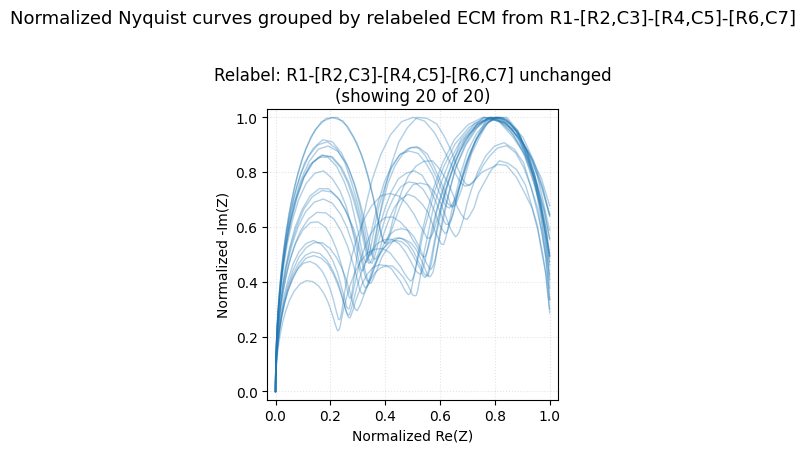

In [ ]:
# Plot a smaller check set of per-curve normalized Nyquist curves grouped by final relabeled ECM.

import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

if 'target_dataset_relabelled' not in globals():
    raise RuntimeError('Run the simplification + FIM relabel cell first.')

# Keep the plot readable. Set to None to plot every curve in each relabeled group.
plot_curves_per_relabel = 20
plot_random_state = 42

plot_df = target_dataset_relabelled.dropna(subset=['relabel_ecm']).copy()
if plot_curves_per_relabel is not None:
    sampled_groups = []
    for _, group in plot_df.groupby('relabel_ecm', sort=False):
        sampled_groups.append(
            group.sample(
                n=min(plot_curves_per_relabel, len(group)),
                random_state=plot_random_state,
            )
        )
    plot_df = pd.concat(sampled_groups) if sampled_groups else plot_df.iloc[0:0]

relabel_groups = list(plot_df.groupby('relabel_ecm', sort=True))
if not relabel_groups:
    raise ValueError('No relabeled ECM groups available to plot.')


def normalized_nyquist_from_Z(Z):
    Z = np.asarray(Z)
    re = Z.real
    minus_im = -Z.imag

    re_range = re.max() - re.min()
    minus_im_range = minus_im.max() - minus_im.min()

    re_norm = (re - re.min()) / re_range if re_range > 0 else np.zeros_like(re)
    minus_im_norm = (
        (minus_im - minus_im.min()) / minus_im_range
        if minus_im_range > 0
        else np.zeros_like(minus_im)
    )
    return re_norm, minus_im_norm


n_groups = len(relabel_groups)
n_cols = min(3, n_groups)
n_rows = math.ceil(n_groups / n_cols)
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5.2 * n_cols, 4.4 * n_rows),
    squeeze=False,
)

for ax, (relabel_ecm, group) in zip(axes.ravel(), relabel_groups):
    total_for_label = int((target_dataset_relabelled['relabel_ecm'] == relabel_ecm).sum())
    for _, row in group.iterrows():
        # Use EIS data already stored in the training dataset; normalize for plotting only.
        re_norm, minus_im_norm = normalized_nyquist_from_Z(row['Z_true'])
        ax.plot(re_norm, minus_im_norm, color='tab:blue', alpha=0.35, linewidth=1.0)

    original_count = int((group['original_ecm'] == relabel_ecm).sum()) if 'original_ecm' in group else len(group)
    unchanged_note = ' unchanged' if original_count == len(group) else ''
    ax.set_title(f'Relabel: {relabel_ecm}{unchanged_note}\n(showing {len(group)} of {total_for_label})')
    ax.set_xlabel('Normalized Re(Z)')
    ax.set_ylabel('Normalized -Im(Z)')
    ax.set_xlim(-0.03, 1.03)
    ax.set_ylim(-0.03, 1.03)
    ax.grid(True, linestyle=':', alpha=0.35)
    ax.set_aspect('equal', adjustable='box')

for ax in axes.ravel()[n_groups:]:
    ax.axis('off')

fig.suptitle(f'Normalized Nyquist curves grouped by relabeled ECM from {target_circuit}', y=1.02, fontsize=13)
fig.tight_layout()
plt.show()


Use previous ECM (R-p[P,R]-p[P,R]) randomly generated previoiusly
- Greedy selection & filtering out low freq,  Relabelling,  draw EIS plot separately based with the title of relabelled ECM (one plot for each ECM)

## Random broad-parameter workflow for `R-p[P,R]-p[P,R]`

Generate broad random parameters, simulate EIS curves, filter by the low-frequency endpoint, greedily select 100 diverse normalized Nyquist curves, relabel with simplification then FIM, and plot one normalized EIS panel per relabeled ECM.


In [ ]:
# Broad random parameter generation + low-frequency filtering + greedy selection
# ECM written as R-p[P,R]-p[P,R]; AutoEIS syntax uses R1-[P2,R3]-[P4,R5].

import numpy as np
import autoeis as ae
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

random_ecm_circuit = 'R1-[P2,R3]-[P4,R5]'
random_ecm_param_names = ae.parser.get_parameter_labels(random_ecm_circuit)
random_ecm_freq = np.logspace(5, -2, 80)
random_ecm_fn = ae.utils.generate_circuit_fn(random_ecm_circuit)

# Broad sampling and selection controls.
n_random_candidates = 5000
max_selected_curves = 100
random_seed = 42
selection_distance_threshold = None

# Low-frequency filter controls. Frequency is descending, so index -1 is low frequency.
low_frequency_index = -1
min_low_frequency_re_norm = 0.70
max_low_frequency_minus_im_norm = 0.20


def sample_random_ecm_params(n_candidates=n_random_candidates, seed=random_seed):
    rng = np.random.default_rng(seed)
    samples = []

    bounds = {
        'R1': (1e0, 1e3),
        'R3': (1e0, 1e6),
        'R5': (1e0, 1e6),
        'P2w': (1e-8, 1e-2),
        'P4w': (1e-8, 1e-2),
        'P2n': (0.45, 1.0),
        'P4n': (0.45, 1.0),
    }

    for _ in range(n_candidates):
        row = {}
        for name in random_ecm_param_names:
            lo, hi = bounds[name]
            if name.endswith('n'):
                row[name] = rng.uniform(lo, hi)
            else:
                row[name] = 10 ** rng.uniform(np.log10(lo), np.log10(hi))
        samples.append(row)

    return samples


def param_dict_to_array(params, names=random_ecm_param_names):
    return np.array([params[name] for name in names], dtype=float)


def simulate_random_ecm(params):
    try:
        return random_ecm_fn(random_ecm_freq, param_dict_to_array(params))
    except Exception:
        return None


def normalize_nyquist_curve(Z):
    Z = np.asarray(Z)
    re = Z.real
    minus_im = -Z.imag

    re_range = re.max() - re.min()
    minus_im_range = minus_im.max() - minus_im.min()

    re_norm = (re - re.min()) / re_range if re_range > 0 else np.zeros_like(re)
    minus_im_norm = (
        (minus_im - minus_im.min()) / minus_im_range
        if minus_im_range > 0
        else np.zeros_like(minus_im)
    )
    return re_norm, minus_im_norm


def stack_curves_for_selection(curves):
    if not curves:
        return np.empty((0, 0, 2), dtype=np.float32)

    n_freq = len(curves[0][0])
    curve_points = np.empty((len(curves), n_freq, 2), dtype=np.float32)
    for idx, (re_norm, minus_im_norm) in enumerate(curves):
        curve_points[idx, :, 0] = re_norm
        curve_points[idx, :, 1] = minus_im_norm
    return curve_points


def distances_to_curve(curve_points, reference_curve):
    diff = curve_points - reference_curve[None, :, :]
    return np.sqrt(np.sum(diff * diff, axis=2)).mean(axis=1)


def evaluate_random_candidates(candidates):
    valid_params = []
    valid_Z = []
    valid_curves = []

    for params in tqdm(candidates, desc='Simulating broad random candidates'):
        Z = simulate_random_ecm(params)
        if Z is None or not np.all(np.isfinite(Z)):
            continue
        curve = normalize_nyquist_curve(Z)
        valid_params.append(params)
        valid_Z.append(Z)
        valid_curves.append(curve)

    return valid_params, valid_Z, valid_curves


def filter_low_frequency_curves(
    params_list,
    Z_list,
    curves,
    low_frequency_index=low_frequency_index,
    min_re=min_low_frequency_re_norm,
    max_minus_im=max_low_frequency_minus_im_norm,
):
    low_re = np.asarray([curve[0][low_frequency_index] for curve in curves])
    low_minus_im = np.asarray([curve[1][low_frequency_index] for curve in curves])
    keep_mask = (low_re >= min_re) & (low_minus_im <= max_minus_im)
    kept_idx = np.flatnonzero(keep_mask)

    if len(kept_idx) == 0:
        raise ValueError(
            'Low-frequency filter removed every candidate. Relax '
            'min_low_frequency_re_norm or max_low_frequency_minus_im_norm.'
        )

    filter_info = {
        'raw_valid_candidate_count': len(params_list),
        'filtered_candidate_count': len(kept_idx),
        'removed_candidate_count': int((~keep_mask).sum()),
        'low_frequency_index': low_frequency_index,
        'min_low_frequency_re_norm': min_re,
        'max_low_frequency_minus_im_norm': max_minus_im,
        'kept_original_idx': kept_idx.tolist(),
        'low_frequency_re_norm': low_re.tolist(),
        'low_frequency_minus_im_norm': low_minus_im.tolist(),
    }

    return (
        [params_list[i] for i in kept_idx],
        [Z_list[i] for i in kept_idx],
        [curves[i] for i in kept_idx],
        filter_info,
    )


def choose_initial_curve(curve_points, start='farthest_from_center'):
    if isinstance(start, (int, np.integer)):
        return int(start)
    if start == 'farthest_from_center':
        center_curve = curve_points.mean(axis=0)
        return int(np.argmax(distances_to_curve(curve_points, center_curve)))
    if start == 'random':
        return int(np.random.default_rng(random_seed).integers(len(curve_points)))
    raise ValueError("start must be an index, 'farthest_from_center', or 'random'")


def greedy_select_curves(params_list, Z_list, curves, k=max_selected_curves, min_distance=None):
    if not curves or k <= 0:
        return [], [], [], [], []

    curve_points = stack_curves_for_selection(curves)
    n_select = min(k, len(curves))

    first_idx = choose_initial_curve(curve_points, start='farthest_from_center')
    selected_idx = [first_idx]
    selection_scores = [np.inf]

    min_dist_to_selected = distances_to_curve(curve_points, curve_points[first_idx])
    min_dist_to_selected[first_idx] = -np.inf

    while len(selected_idx) < n_select:
        best_idx = int(np.argmax(min_dist_to_selected))
        best_score = float(min_dist_to_selected[best_idx])
        if min_distance is not None and best_score < min_distance:
            break

        selected_idx.append(best_idx)
        selection_scores.append(best_score)
        new_dist = distances_to_curve(curve_points, curve_points[best_idx])
        min_dist_to_selected = np.minimum(min_dist_to_selected, new_dist)
        min_dist_to_selected[selected_idx] = -np.inf

    return (
        [params_list[i] for i in selected_idx],
        [Z_list[i] for i in selected_idx],
        [curves[i] for i in selected_idx],
        selected_idx,
        selection_scores,
    )


random_candidates = sample_random_ecm_params()
random_param_list, random_Z_list, random_curves = evaluate_random_candidates(random_candidates)
(
    filtered_random_params,
    filtered_random_Z,
    filtered_random_curves,
    low_frequency_filter_info,
) = filter_low_frequency_curves(random_param_list, random_Z_list, random_curves)

(
    selected_random_params,
    selected_random_Z,
    selected_random_curves,
    selected_random_idx,
    selected_random_scores,
) = greedy_select_curves(
    filtered_random_params,
    filtered_random_Z,
    filtered_random_curves,
    k=max_selected_curves,
    min_distance=selection_distance_threshold,
)

print(
    f"Low-frequency filter kept {low_frequency_filter_info['filtered_candidate_count']} "
    f"of {low_frequency_filter_info['raw_valid_candidate_count']} valid candidates "
    f"(re_norm[{low_frequency_index}] >= {min_low_frequency_re_norm}, "
    f"-im_norm[{low_frequency_index}] <= {max_low_frequency_minus_im_norm})"
)
print(f'Selected {len(selected_random_curves)} diverse curves')


Simulating broad random candidates:   0%|          | 0/5000 [00:00<?, ?it/s]

Low-frequency filter kept 3072 of 5000 valid candidates (re_norm[-1] >= 0.7, -im_norm[-1] <= 0.2)
Selected 100 diverse curves


In [ ]:
# Simplify first, then run FIM redundancy relabeling on the selected random curves.

import sys
from pathlib import Path

import pandas as pd
from tqdm.auto import tqdm

simplification_dir = Path('ecm_simplification_functions').resolve()
if str(simplification_dir) not in sys.path:
    sys.path.insert(0, str(simplification_dir))

import parser as ecm_parser_simplifier
from drop_ecm_redundancy import full_simplify_redundant_circuit

fim_fit_ecm = True


def choose_fim_relabel(fim_result, fallback_circuit, fallback_params):
    if isinstance(fim_result, str):
        return fim_result, fallback_params, []
    if isinstance(fim_result, list) and fim_result:
        first = fim_result[0]
        if isinstance(first, tuple):
            return first[0], first[1], fim_result
        return first, None, fim_result
    return fallback_circuit, fallback_params, fim_result


random_relabel_rows = []
for selected_position, (params, Z, curve) in enumerate(
    tqdm(
        zip(selected_random_params, selected_random_Z, selected_random_curves),
        total=len(selected_random_params),
        desc='Simplify + FIM relabel selected curves',
    )
):
    record = {
        'selected_position': selected_position,
        'original_ecm': random_ecm_circuit,
        'simplified_ecm': None,
        'fim_relabel_ecm': None,
        'relabel_ecm': None,
        'params': params,
        'simplified_params': None,
        'relabel_params': None,
        'fim_candidates': None,
        'Z': Z,
        'curve': curve,
        'relabel_failed': False,
        'failure_reason': None,
    }

    try:
        simplified_ecm, simplified_params = ecm_parser_simplifier.simplify(
            random_ecm_circuit,
            params,
        )
        fim_result = full_simplify_redundant_circuit(
            simplified_ecm,
            random_ecm_freq,
            Z,
            simplified_params,
            fit_ecm=fim_fit_ecm,
            verbose=False,
        )
        relabel_ecm, relabel_params, fim_candidates = choose_fim_relabel(
            fim_result,
            simplified_ecm,
            simplified_params,
        )
        record.update({
            'simplified_ecm': simplified_ecm,
            'fim_relabel_ecm': relabel_ecm,
            'relabel_ecm': relabel_ecm,
            'simplified_params': simplified_params,
            'relabel_params': relabel_params,
            'fim_candidates': fim_candidates,
        })
    except Exception as exc:
        record.update({
            'simplified_ecm': random_ecm_circuit,
            'fim_relabel_ecm': random_ecm_circuit,
            'relabel_ecm': random_ecm_circuit,
            'relabel_failed': True,
            'failure_reason': repr(exc),
        })

    random_relabel_rows.append(record)

random_relabel_results_df = pd.DataFrame(random_relabel_rows)
print('Relabel counts:')
print(random_relabel_results_df['relabel_ecm'].value_counts(dropna=False))
print(f"Failures: {int(random_relabel_results_df['relabel_failed'].sum())} / {len(random_relabel_results_df)}")
random_relabel_results_df[['selected_position', 'original_ecm', 'simplified_ecm', 'relabel_ecm', 'relabel_failed']].head()


Simplify + FIM relabel selected curves:   0%|          | 0/100 [00:00<?, ?it/s]

Relabel counts:
relabel_ecm
R1-[P2,R3]-R5         10
R1-R3-[P4,R5]         10
[P2,R3]-R5            10
R3-R5                  7
R1-[P2,R3]-[C4,R5]     7
R1-[C2,R3]-[C4,R5]     7
R1-[P2,R3]-[P4,R5]     5
R1-R3-[C4,R5]          4
[P2,R3]-[C4,R5]        4
R1-R3-R5               4
[P2,R3]-[P4,R5]        4
R1-[C4,R5]             3
R3-[P4,R5]             3
R1-[P4,R5]             3
R1-[C2,R3]-[P4,R5]     3
[P4,R5]                2
R1-P2-[P4,R5]          2
R1-[C2,R3]-R5          2
[C2,R3]-[P4,R5]        2
R1-R5                  2
R1-R3                  1
R1                     1
R1-[P2,R3]-P4          1
R1-C2-[C4,R5]          1
[C2,R3]-R5             1
[P2,R3]                1
Name: count, dtype: int64
Failures: 0 / 100


,selected_position,original_ecm,simplified_ecm,relabel_ecm,relabel_failed
0,0,"R1-[P2,R3]-[P4,R5]","R1-[C2,R3]-[P4,R5]","R1-[C2,R3]-R5",False
1,1,"R1-[P2,R3]-[P4,R5]","R1-[P2,R3]-[P4,R5]",R3-R5,False
2,2,"R1-[P2,R3]-[P4,R5]","R1-[P2,R3]-[P4,R5]","R1-R3-[P4,R5]",False
3,3,"R1-[P2,R3]-[P4,R5]","R1-[P2,R3]-[P4,R5]","R1-R3-[P4,R5]",False
4,4,"R1-[P2,R3]-[P4,R5]","R1-[P2,R3]-[P4,R5]","[P2,R3]-R5",False


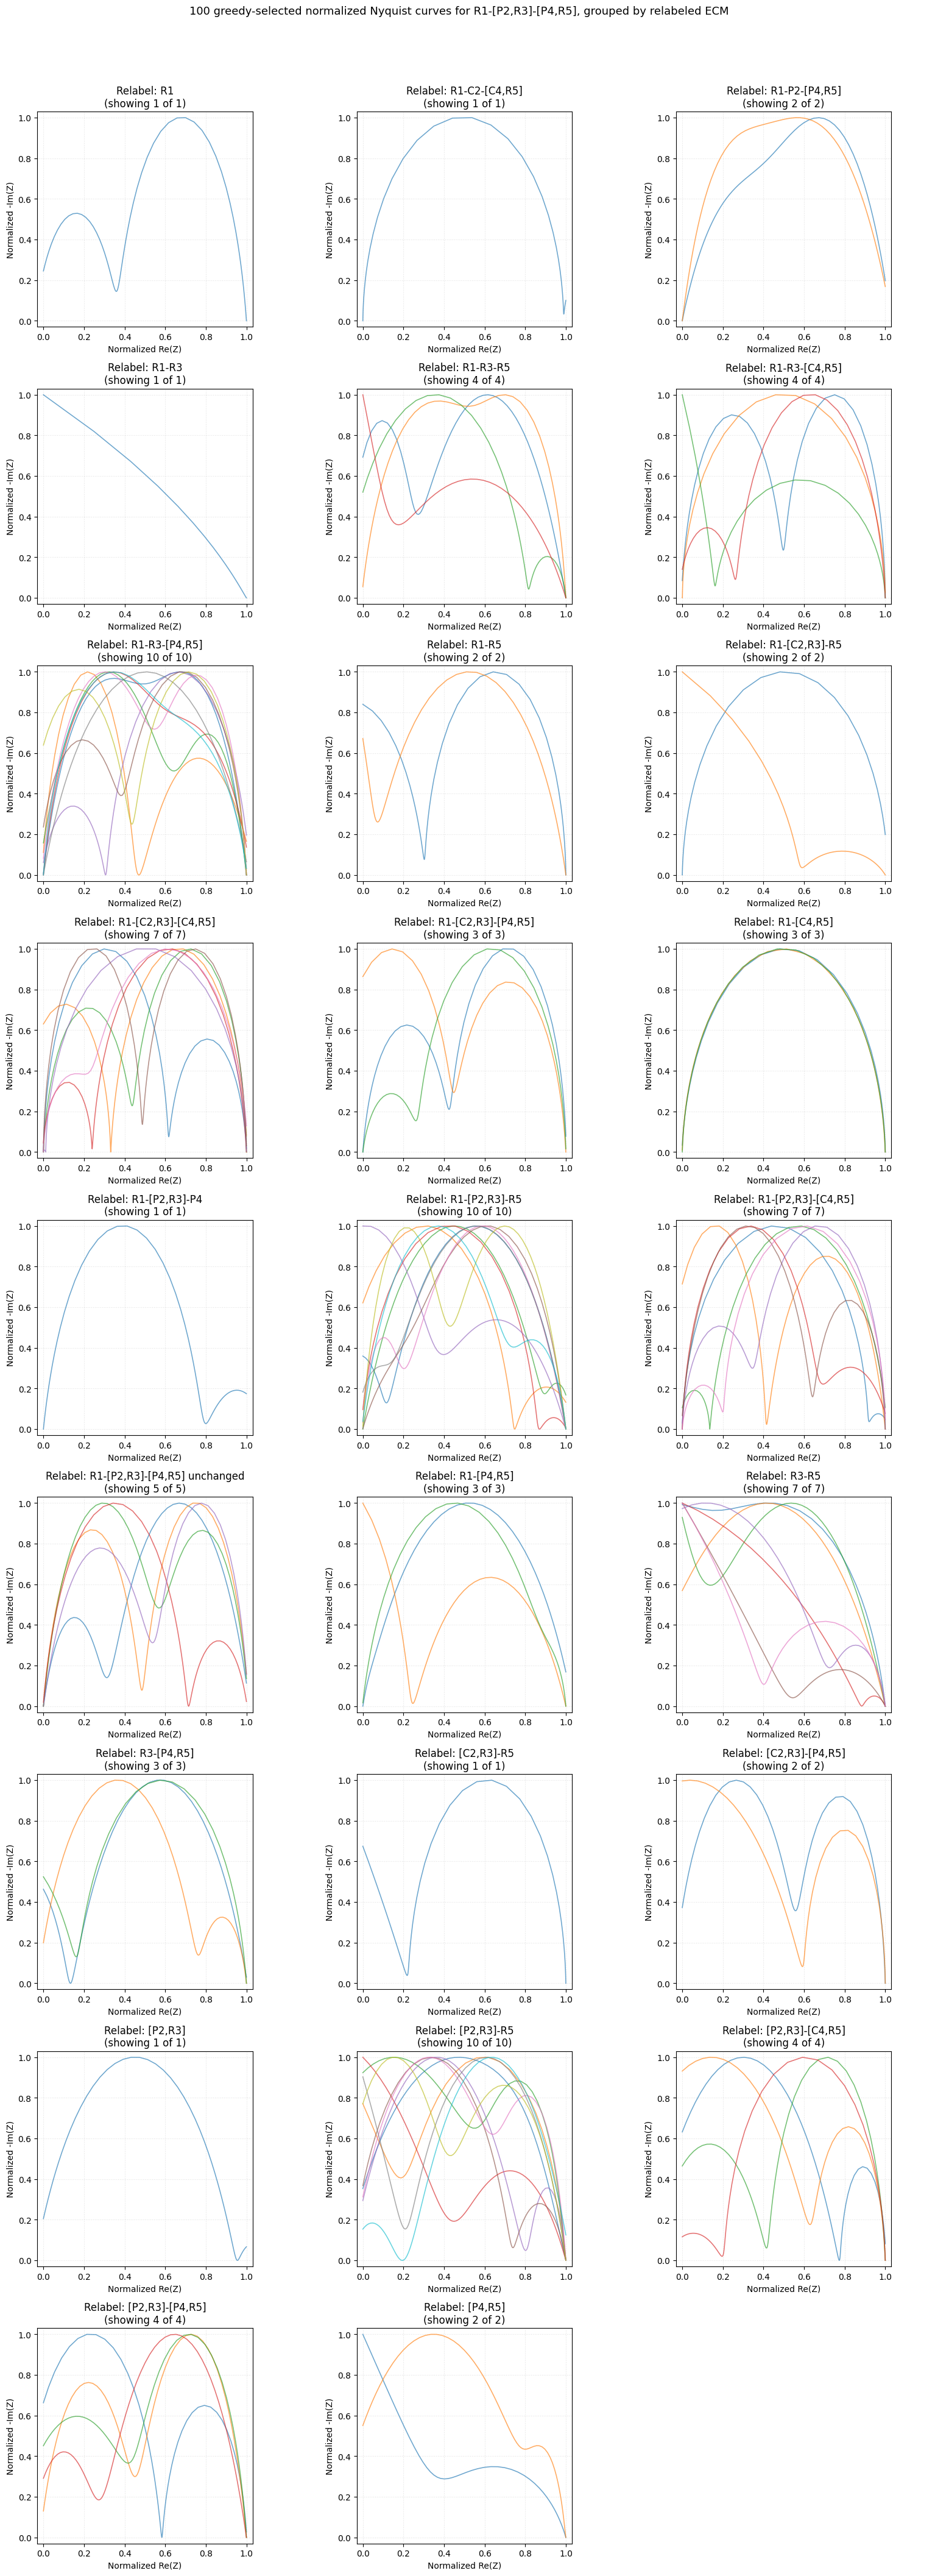

In [ ]:
# Draw the 100 selected normalized Nyquist curves, split by relabeled ECM.

import math

plot_selected_per_relabel = None  # None means plot all selected curves in each relabel group.
plot_random_state = 42

plot_random_relabel_df = random_relabel_results_df.dropna(subset=['relabel_ecm']).copy()
if plot_selected_per_relabel is not None:
    sampled_groups = []
    for _, group in plot_random_relabel_df.groupby('relabel_ecm', sort=False):
        sampled_groups.append(
            group.sample(
                n=min(plot_selected_per_relabel, len(group)),
                random_state=plot_random_state,
            )
        )
    plot_random_relabel_df = (
        pd.concat(sampled_groups) if sampled_groups else plot_random_relabel_df.iloc[0:0]
    )

relabel_groups = list(plot_random_relabel_df.groupby('relabel_ecm', sort=True))
if not relabel_groups:
    raise ValueError('No relabeled ECM groups available to plot.')

n_groups = len(relabel_groups)
n_cols = min(3, n_groups)
n_rows = math.ceil(n_groups / n_cols)
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5.4 * n_cols, 4.6 * n_rows),
    squeeze=False,
)

for ax, (relabel_ecm, group) in zip(axes.ravel(), relabel_groups):
    total_for_label = int((random_relabel_results_df['relabel_ecm'] == relabel_ecm).sum())
    for _, row in group.iterrows():
        re_norm, minus_im_norm = row['curve']
        ax.plot(re_norm, minus_im_norm, linewidth=1.15, alpha=0.65)

    original_count = int((group['original_ecm'] == relabel_ecm).sum())
    unchanged_note = ' unchanged' if original_count == len(group) else ''
    ax.set_title(f'Relabel: {relabel_ecm}{unchanged_note}\n(showing {len(group)} of {total_for_label})')
    ax.set_xlabel('Normalized Re(Z)')
    ax.set_ylabel('Normalized -Im(Z)')
    ax.set_xlim(-0.03, 1.03)
    ax.set_ylim(-0.03, 1.03)
    ax.grid(True, linestyle=':', alpha=0.35)
    ax.set_aspect('equal', adjustable='box')

for ax in axes.ravel()[n_groups:]:
    ax.axis('off')

fig.suptitle(
    f'{len(plot_random_relabel_df)} greedy-selected normalized Nyquist curves for {random_ecm_circuit}, grouped by relabeled ECM',
    y=1.02,
    fontsize=13,
)
fig.tight_layout()
plt.show()


Add a group of [R,P], trying to generate a broad number of samples, doing the processing, after filtering, if it's not getting a uniform dataset for each ECM types, we store the current dataset, and iterate generating until the dataset reaches 200 for each ECM

# Singular ECM Structure Pipeline 

### Currently working: ECM generation --> EIS data generation --> Optimization & Filtering

In [7]:
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
import random
from param_gen import (
    GenerateImpedance,
    process_impedances_norm,
    pointsPerDecade
)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os

import sys
import autoeis as ae 
import umap

In [8]:
def generate_moderate_ecm(seed=None):
    """
    Generate ONE moderate ECM in the correct format:
    R0-p(R1,CPE1)-R2-L1 ...
    """

    rng = random.Random(seed)

    resistors = ["R0", "R1", "R2", "R3"]
    cpes = ["CPE0", "CPE1", "CPE2", "CPE3"]
    caps = ["C1", "C2", "C3"]
    warburg = ["Wo1"]
    inductors = ["L1", "L2"]

    def p(a, b):
        return f"p({a},{b})"

    structure_type = rng.choice([
        "single_RC",
        "two_RC",
        "warburg_RC",
        "inductive_RC"
    ])

    if structure_type == "single_RC":
        r = rng.choice(resistors)
        c = rng.choice(cpes)
        ecm = f"R0-{p(r, c)}"

    elif structure_type == "two_RC":
        r1, r2 = rng.sample(resistors, 2)
        c1, c2 = rng.sample(cpes, 2)
        ecm = f"R0-{p(r1, c1)}-{p(r2, c2)}"

    elif structure_type == "warburg_RC":
        r1, r2 = rng.sample(resistors, 2)
        c1 = rng.choice(cpes)
        w = rng.choice(warburg)
        ecm = f"R0-{p(r1, c1)}-{p(r2, w)}"

    elif structure_type == "inductive_RC":
        r1, r2 = rng.sample(resistors, 2)
        c1 = rng.choice(cpes)
        l = rng.choice(inductors)
        ecm = f"R0-{p(r1, c1)}-{l}-{r2}"

    return ecm

In [10]:
def optimized_eis_from_dataset(
    dataset,
    circuit,
    k_select=100,
    max_high_frequency_minus_im=-0.8,
    seed=42,
    plot=True,
    plot_pca=True,
    save_path=None
):
    rng = np.random.default_rng(seed)

    curves_raw = dataset[circuit]["curves"]

    # =====================================================
    # 1. NORMALIZE CURVES (consistent representation)
    # =====================================================
    raw_curves = []

    for Z in curves_raw:
        re = Z.real
        im = Z.imag

        re_norm = (re - re.min()) / (re.max() - re.min() + 1e-12)
        im_norm = (im - im.min()) / (im.max() - im.min() + 1e-12)

        raw_curves.append((re_norm, im_norm))

    # =====================================================
    # 2. FILTER
    # =====================================================
    hf_vals = np.array([-c[1][0] for c in raw_curves])
    mask = hf_vals <= max_high_frequency_minus_im

    curves = [c for i, c in enumerate(raw_curves) if mask[i]]

    if len(curves) == 0:
        raise ValueError("All curves filtered out")

    # =====================================================
    # 3. STACK FOR DIVERSITY SEARCH
    # =====================================================
    curve_points = np.stack([
        np.stack([c[0], c[1]], axis=1)
        for c in curves
    ])

    def dist(X, ref):
        diff = X - ref[None, :, :]
        return np.sqrt(np.sum(diff**2, axis=2)).mean(axis=1)

    # =====================================================
    # 4. GREEDY DIVERSITY SELECTION
    # =====================================================
    n_select = min(k_select, len(curves))

    center = curve_points.mean(axis=0)
    first = int(np.argmax(dist(curve_points, center)))

    selected = [first]
    min_d = dist(curve_points, curve_points[first])

    while len(selected) < n_select:
        min_d[selected] = -1
        nxt = int(np.argmax(min_d))

        selected.append(nxt)
        new_d = dist(curve_points, curve_points[nxt])
        min_d = np.minimum(min_d, new_d)

    selected_curves = [curves[i] for i in selected]

    # =====================================================
    # 5. METRICS
    # =====================================================
    def curve_distance(a, b):
        A = np.vstack(a).T
        B = np.vstack(b).T
        return np.mean(np.linalg.norm(A - B, axis=1))

    def diversity(cs):
        if len(cs) < 2:
            return 0
        return np.mean([
            curve_distance(cs[i], cs[j])
            for i in range(len(cs))
            for j in range(i+1, len(cs))
        ])

    print("\n===== OPTIMIZATION SUMMARY =====")
    print(f"Total: {len(curves_raw)} → Filtered: {len(curves)} → Selected: {len(selected)}")
    print(f"Diversity before: {diversity(curves):.4f}")
    print(f"Diversity after : {diversity(selected_curves):.4f}")

    # =====================================================
    # 6. PLOT NYQUIST
    # =====================================================
    if plot:
        plt.figure(figsize=(7, 6))

        for re, im in curves:
            plt.plot(re, -im, color='gray', alpha=0.2)

        for i in selected:
            re, im = curves[i]
            plt.plot(re, -im, linewidth=2.5)

        plt.title("Optimized Nyquist (from dataset)")
        plt.xlabel("Re(Z)")
        plt.ylabel("-Im(Z)")
        plt.grid(True)
        plt.show()

    # =====================================================
    # 7. PCA (CURVE SPACE ONLY — CLEAN)
    # =====================================================
    if plot_pca:
        Xc = curve_points.reshape(len(curves), -1)
        Xc = StandardScaler().fit_transform(Xc)
        scores = PCA(n_components=2).fit_transform(Xc)

        plt.figure(figsize=(6, 5))
        plt.scatter(scores[:, 0], scores[:, 1], alpha=0.5, color='gray')
        plt.scatter(scores[selected, 0], scores[selected, 1], color='red')
        plt.title("Curve PCA (Dataset Space)")
        plt.grid(True)
        plt.show()

    # =====================================================
    # 8. SAVE
    # =====================================================
    result = {
        "selected_idx": selected,
        "curves_selected": selected_curves
    }

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        with open(save_path, "wb") as f:
            pickle.dump(result, f)

    return result

In [9]:
def generate_eis_dataset(circuits, normalize_dataset=True):
    frequencies = pointsPerDecade(5, -2, 10)

    # parameter grids (your original working setup)
    R = (
        np.linspace(1, 100, 20),
        np.linspace(1, 500, 20),
        np.linspace(1, 500, 20),
        np.linspace(1, 500, 20),
    )

    C = (
        np.logspace(-6, -2, 20),
        np.logspace(-6, -2, 20),
        np.logspace(-6, -2, 20),
        np.logspace(-6, -2, 20),
    )

    CPE = (
        np.logspace(-5, -2, 20),
        np.logspace(-5, -2, 20),
        np.logspace(-5, -2, 20),
        np.logspace(-5, -2, 20),
    )

    CPE_alpha = np.linspace(0.5, 1.0, 10)

    L = (
        np.logspace(-6, -3, 10),
        np.logspace(-6, -3, 10),
        np.logspace(-6, -3, 10),
        np.logspace(-6, -3, 10),
    )

    Wo_0 = np.logspace(-2, 2, 20)
    Wo_1 = np.logspace(-2, 2, 20)

    dataset = {}

    for circuit in circuits:
        print(f"Generating: {circuit}")

        Z_list = GenerateImpedance(
            R=R, C=C, CPE=CPE, CPE_alpha=CPE_alpha,
            L=L, Wo_0=Wo_0, Wo_1=Wo_1,
            circuit=circuit,
            frequencies=frequencies
        )

        if normalize_dataset:
            Z_list = process_impedances_norm(Z_list)

        dataset[circuit] = {
            "curves": Z_list,
            "frequencies": frequencies
        }

    return dataset

Generating: R0-p(R2,CPE0)-L2-R0
['R0', 'R2', 'CPE0', 'CPE_alpha0', 'L2', 'R0']
[[94.78947368421052, 447.4736842105263, 1.438449888287663e-05, 0.7777777777777778, 1e-06, 6.2105263157894735], [27.052631578947366, 473.7368421052632, 0.00018329807108324357, 0.5, 2.1544346900318822e-06, 100.0], [47.89473684210526, 421.2105263157895, 0.00026366508987303583, 0.8333333333333333, 4.641588833612772e-05, 63.526315789473685], [42.68421052631579, 27.263157894736842, 0.001623776739188721, 0.9444444444444444, 2.1544346900318822e-06, 63.526315789473685], [32.26315789473684, 473.7368421052632, 0.000379269019073225, 0.6666666666666666, 0.00021544346900318823, 63.526315789473685], [47.89473684210526, 421.2105263157895, 0.01, 0.6666666666666666, 4.641588833612782e-06, 58.315789473684205], [100.0, 53.526315789473685, 0.001623776739188721, 0.8333333333333333, 0.001, 32.26315789473684], [6.2105263157894735, 394.94736842105266, 0.00012742749857031334, 0.6666666666666666, 0.00021544346900318823, 58.31578947368

100%|██████████| 100/100 [00:00<00:00, 1562.51it/s]


===== OPTIMIZATION SUMMARY =====
Total: 100 → Filtered: 73 → Selected: 50
Diversity before: 0.3926
Diversity after : 0.4136



c:\Users\gyl19\OneDrive - University of Toronto\Year 2 ECE\summer26\AutoREC\param_gen.py:213: RuntimeWarning: divide by zero encountered in divide
  modulus_val = modulus_val / max(modulus_val)
c:\Users\gyl19\OneDrive - University of Toronto\Year 2 ECE\summer26\AutoREC\param_gen.py:213: RuntimeWarning: invalid value encountered in divide
  modulus_val = modulus_val / max(modulus_val)
c:\Users\gyl19\OneDrive - University of Toronto\Year 2 ECE\summer26\AutoREC\param_gen.py:242: RuntimeWarning: invalid value encountered in multiply
  impedances_blocking_normalized.append(np.array(real) + 1j * np.array(imag))


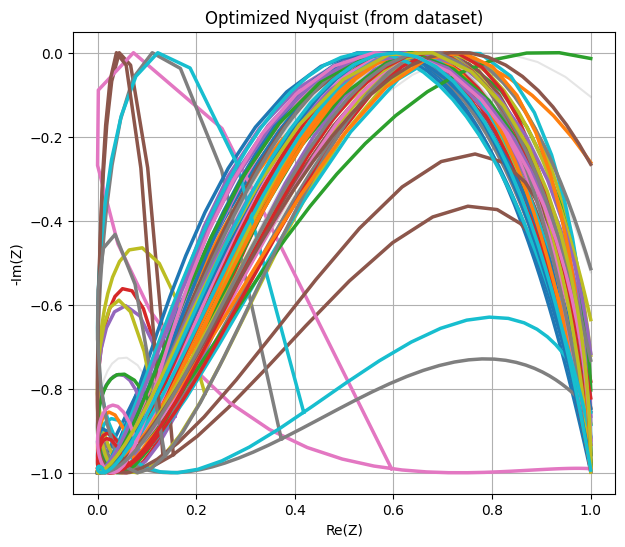

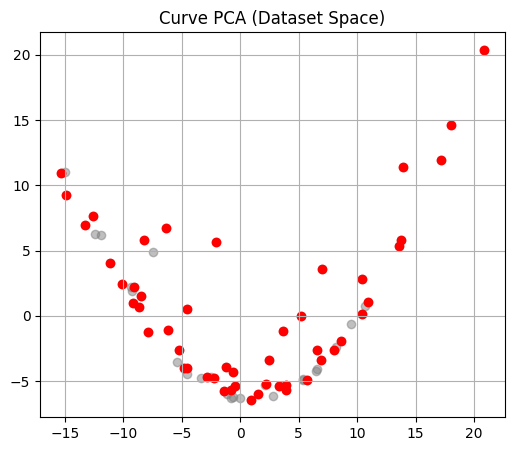

In [11]:
circuits = [generate_moderate_ecm()]

# STEP 1: generate dataset
dataset = generate_eis_dataset(circuits)

# STEP 2: optimize selection
result = optimized_eis_from_dataset(
    dataset=dataset,
    circuit=circuits[0],
    k_select=50,
    plot=True,
    plot_pca=True
)